In [1]:
import io
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, Image

# ── change this path to load a different trial ────────────────────────────
# FILE_PATH = "/home/metamobility3/Jinwoo/os_kinetics/cascade_0502_gain_0p3.npz"
FILE_PATH = "/home/metamobility3/Jinwoo/os_kinetics/hipV1_0507_jinwoo.npz"
# ──────────────────────────────────────────────────────────────────────────

In [2]:
d = np.load(FILE_PATH, allow_pickle=True)
print(f"Loaded : {os.path.basename(FILE_PATH)}")
print(f"Keys   : {list(d.keys())}")

time   = d["time"]
dt     = float(np.median(np.diff(time)))
fs     = 1.0 / dt
dur    = time[-1] - time[0]
n      = len(time)

# motor encoders (rad)
hip_pos_R = d["hip_pos_R"]
hip_pos_L = d["hip_pos_L"]

# motor velocities (rad/s)
hip_vel_R = d["hip_vel_R"]
hip_vel_L = d["hip_vel_L"]

# IMU gyros — Gyr_Y (index 4, deg/s) used for hip flex/ext velocity
gyro_P = d["imu_P"][:, 4]   # pelvis
gyro_R = d["imu_R"][:, 4]   # right thigh
gyro_L = d["imu_L"][:, 4]   # left thigh

# model I/O  (right-side reference channel logged by main_hip.py)
model_in_angle = d["model_in_angle_raw"]   # rad
model_in_vel   = d["model_in_vel_raw"]     # rad/s
model_out_R    = d["model_out_R"]          # Nm/kg
model_out_L    = d["model_out_L"]          # Nm/kg

# commands and applied torques (Nm)
cmd_R     = d["cmd_R"]
cmd_L     = d["cmd_L"]
applied_R = d["applied_R"]
applied_L = d["applied_L"]

# motion gate
assist_gate  = d["assist_gate"]
motion_score = d["motion_score"]
state        = d["state"]
gpio         = d["GPIO"]

print(f"Duration : {dur:.1f} s   fs ≈ {fs:.1f} Hz   samples : {n}")
print(f"cmd_R    : [{cmd_R.min():.2f}, {cmd_R.max():.2f}] Nm")
print(f"cmd_L    : [{cmd_L.min():.2f}, {cmd_L.max():.2f}] Nm")

Loaded : hipV1_0507_jinwoo.npz
Keys   : ['time', 'hip_pos_L', 'hip_pos_R', 'hip_vel_L', 'hip_vel_R', 'cmd_L', 'cmd_R', 'model_out_L', 'model_out_R', 'applied_L', 'applied_R', 'imu_P', 'imu_L', 'imu_R', 'GPIO', 'model_in_angle_raw', 'model_in_vel_raw', 'model_out_nmpkg', 'moment_raw', 'assist_gate', 'motion_score', 'state']
Duration : 149.6 s   fs ≈ 100.0 Hz   samples : 14961
cmd_R    : [-8.25, 4.71] Nm
cmd_L    : [-7.49, 4.69] Nm


In [3]:
PALETTE = {
    "R"     : "#2196F3",
    "L"     : "#FF9800",
    "model" : "#9C27B0",
    "gate"  : "#4CAF50",
    "score" : "#795548",
    "gpio"  : "#607D8B",
    "pelvis": "#E91E63",
}

out = widgets.Output()

slider = widgets.FloatRangeSlider(
    value=[time[0], time[-1]],
    min=time[0], max=time[-1], step=0.1,
    description="Time (s):",
    layout=widgets.Layout(width="760px"),
    style={"description_width": "initial"},
    continuous_update=False,
    readout_format=".1f",
)


def _draw(t0, t1):
    m = (time >= t0) & (time <= t1)
    t = time[m]

    fig, axs = plt.subplots(6, 1, figsize=(16, 18), sharex=True)

    # 1 — Hip encoder angles
    axs[0].plot(t, np.rad2deg(hip_pos_R[m]), color=PALETTE["R"], lw=1.5, label="Right")
    axs[0].plot(t, np.rad2deg(hip_pos_L[m]), color=PALETTE["L"], lw=1.5, label="Left")
    axs[0].axhline(0, color="gray", lw=0.7, ls="--")
    axs[0].set_ylabel("Hip angle (deg)", fontsize=12)
    axs[0].legend(fontsize=10, loc="upper right")

    # 2 — Model inputs (right-side reference)
    ax2b = axs[1].twinx()
    axs[1].plot(t, np.rad2deg(model_in_angle[m]), color=PALETTE["R"],     lw=1.5, label="Hip angle — model in (deg)")
    ax2b.plot(   t, np.rad2deg(model_in_vel[m]),  color=PALETTE["model"], lw=1.2, ls="--", label="Hip vel — model in (deg/s)")
    axs[1].axhline(0, color="gray", lw=0.7, ls="--")
    axs[1].set_ylabel("Angle (deg)", fontsize=12)
    ax2b.set_ylabel("Vel (deg/s)",  fontsize=12, color=PALETTE["model"])
    lines1, labels1 = axs[1].get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    axs[1].legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")

    # 3 — Model outputs (Nm/kg)
    axs[2].plot(t, model_out_R[m], color=PALETTE["R"], lw=1.5, label="model_out R (Nm/kg)")
    axs[2].plot(t, model_out_L[m], color=PALETTE["L"], lw=1.5, label="model_out L (Nm/kg)")
    axs[2].axhline(0, color="gray", lw=0.7, ls="--")
    axs[2].set_ylabel("Model out (Nm/kg)", fontsize=12)
    axs[2].legend(fontsize=10, loc="upper right")

    # 4 — Motor commands (Nm)
    axs[3].plot(t, cmd_R[m],     color=PALETTE["R"], lw=1.5, label="cmd R (Nm)")
    axs[3].plot(t, cmd_L[m],     color=PALETTE["L"], lw=1.5, label="cmd L (Nm)")
    axs[3].axhline(0, color="gray", lw=0.7, ls="--")
    axs[3].set_ylabel("Motor cmd (Nm)", fontsize=12)
    axs[3].legend(fontsize=10, loc="upper right")

    # 5 — IMU Gyr_Y (deg/s) for all three IMUs
    axs[4].plot(t, gyro_R[m], color=PALETTE["R"],     lw=1.2, label="Thigh R Gyr_Y")
    axs[4].plot(t, gyro_L[m], color=PALETTE["L"],     lw=1.2, label="Thigh L Gyr_Y")
    axs[4].plot(t, gyro_P[m], color=PALETTE["pelvis"], lw=1.2, label="Pelvis Gyr_Y")
    axs[4].axhline(0, color="gray", lw=0.7, ls="--")
    axs[4].set_ylabel("Gyr_Y (deg/s)", fontsize=12)
    axs[4].legend(fontsize=10, loc="upper right")

    # 6 — Assist gate, motion score, state, GPIO
    axs[5].plot(t, assist_gate[m],  color=PALETTE["gate"],  lw=1.5, label="Assist gate")
    axs[5].plot(t, motion_score[m], color=PALETTE["score"], lw=1.2, ls="--", label="Motion score")
    axs[5].plot(t, state[m] / 2,    color="#FF5722",        lw=1.0, ls=":",  label="State /2")
    axs[5].plot(t, gpio[m],         color=PALETTE["gpio"],  lw=1.5, label="GPIO")
    axs[5].set_ylabel("Gate / score", fontsize=12)
    axs[5].set_xlabel("Time (s)", fontsize=12)
    axs[5].legend(fontsize=10, loc="upper right")

    for ax in axs:
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=10)

    fig.suptitle(os.path.basename(FILE_PATH), fontsize=13)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    buf.seek(0)
    out.clear_output(wait=True)
    with out:
        display(Image(data=buf.read()))


def _on_slider(change):
    _draw(*slider.value)

slider.observe(_on_slider, names="value")
display(slider, out)
_draw(time[0], time[-1])

FloatRangeSlider(value=(0.010119947999953638, 149.610034735), continuous_update=False, description='Time (s):'…

Output()

In [4]:
# ── summary statistics for the current slider window ─────────────────────
t0_s, t1_s = slider.value
m = (time >= t0_s) & (time <= t1_s)

signals = {
    "Hip angle R (deg)"      : np.rad2deg(hip_pos_R[m]),
    "Hip angle L (deg)"      : np.rad2deg(hip_pos_L[m]),
    "Model in angle (deg)"   : np.rad2deg(model_in_angle[m]),
    "Model in vel (deg/s)"   : np.rad2deg(model_in_vel[m]),
    "Model out R (Nm/kg)"    : model_out_R[m],
    "Model out L (Nm/kg)"    : model_out_L[m],
    "Cmd R (Nm)"             : cmd_R[m],
    "Cmd L (Nm)"             : cmd_L[m],
    "Assist gate"            : assist_gate[m],
    "Motion score"           : motion_score[m],
}

print(f"Window: {t0_s:.1f} – {t1_s:.1f} s  ({m.sum()} samples)")
print(f"{'Signal':<26} {'min':>8} {'max':>8} {'mean':>8} {'std':>8}")
print("-" * 62)
for name, sig in signals.items():
    print(f"{name:<26} {sig.min():8.3f} {sig.max():8.3f} {sig.mean():8.3f} {sig.std():8.3f}")

Window: 0.0 – 149.6 s  (14961 samples)
Signal                          min      max     mean      std
--------------------------------------------------------------
Hip angle R (deg)           -31.100   45.400    7.724   19.429
Hip angle L (deg)           -29.400   41.300    6.690   18.202
Model in angle (deg)        -31.100   45.400    7.724   19.429
Model in vel (deg/s)       -161.008  284.214    1.121   95.754
Model out R (Nm/kg)          -0.814    0.475   -0.044    0.276
Model out L (Nm/kg)          -0.736    0.474   -0.048    0.269
Cmd R (Nm)                   -8.252    4.708   -0.462    2.812
Cmd L (Nm)                   -7.489    4.693   -0.508    2.745
Assist gate                   0.000    0.000    0.000    0.000
Motion score                  0.000    0.000    0.000    0.000


In [5]:
# ── Per side (R / L): kinematics on one axis pair; model output vs motor cmd on another ──
# Requires cells above through data load + PALETTE from the overview plot cell.

out_side = widgets.Output()

slider_side = widgets.FloatRangeSlider(
    value=[time[0], time[-1]],
    min=float(time[0]),
    max=float(time[-1]),
    step=0.1,
    description="Time window (s):",
    layout=widgets.Layout(width="760px"),
    style={"description_width": "initial"},
    continuous_update=False,
    readout_format=".1f",
)


def _draw_per_side(t0, t1):
    m = (time >= t0) & (time <= t1)
    t = time[m]
    twin_axes = []

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

    # ----- Row 0: Right -----
    ax_a = axes[0, 0]
    ax_ab = ax_a.twinx()
    twin_axes.append(ax_ab)
    ax_a.plot(t, np.rad2deg(hip_pos_R[m]), color=PALETTE["R"], lw=1.5, label="angle")
    ax_ab.plot(t, np.rad2deg(hip_vel_R[m]), color=PALETTE["model"], lw=1.2, ls="--", label="ω")
    ax_a.axhline(0, color="gray", lw=0.7, ls="--")
    ax_a.set_ylabel("Angle (deg)", fontsize=11)
    ax_ab.set_ylabel("ω (deg/s)", fontsize=11, color=PALETTE["model"])
    ax_ab.tick_params(axis="y", labelcolor=PALETTE["model"])
    ax_a.set_title("Right — hip angle & ω (motor enc)")
    l1, lb1 = ax_a.get_legend_handles_labels()
    l2, lb2 = ax_ab.get_legend_handles_labels()
    ax_a.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper right")

    ax_m = axes[0, 1]
    ax_mb = ax_m.twinx()
    twin_axes.append(ax_mb)
    ax_m.plot(t, model_out_R[m], color=PALETTE["R"], lw=1.5, label="model_out (Nm/kg)")
    ax_mb.plot(t, cmd_R[m], color="#37474F", lw=1.2, ls="--", label="motor cmd (Nm)")
    ax_m.axhline(0, color="gray", lw=0.7, ls="--")
    ax_m.set_ylabel("Model out (Nm/kg)", fontsize=11)
    ax_mb.set_ylabel("Cmd (Nm)", fontsize=11, color="#37474F")
    ax_mb.tick_params(axis="y", labelcolor="#37474F")
    ax_m.set_title("Right — model vs command")
    l1, lb1 = ax_m.get_legend_handles_labels()
    l2, lb2 = ax_mb.get_legend_handles_labels()
    ax_m.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper right")

    # ----- Row 1: Left -----
    ax_a = axes[1, 0]
    ax_ab = ax_a.twinx()
    twin_axes.append(ax_ab)
    ax_a.plot(t, np.rad2deg(hip_pos_L[m]), color=PALETTE["L"], lw=1.5, label="angle")
    ax_ab.plot(t, np.rad2deg(hip_vel_L[m]), color=PALETTE["model"], lw=1.2, ls="--", label="ω")
    ax_a.axhline(0, color="gray", lw=0.7, ls="--")
    ax_a.set_ylabel("Angle (deg)", fontsize=11)
    ax_ab.set_ylabel("ω (deg/s)", fontsize=11, color=PALETTE["model"])
    ax_ab.tick_params(axis="y", labelcolor=PALETTE["model"])
    ax_a.set_title("Left — hip angle & ω (motor enc)")
    ax_a.set_xlabel("Time (s)", fontsize=11)
    l1, lb1 = ax_a.get_legend_handles_labels()
    l2, lb2 = ax_ab.get_legend_handles_labels()
    ax_a.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper right")

    ax_m = axes[1, 1]
    ax_mb = ax_m.twinx()
    twin_axes.append(ax_mb)
    ax_m.plot(t, model_out_L[m], color=PALETTE["L"], lw=1.5, label="model_out (Nm/kg)")
    ax_mb.plot(t, cmd_L[m], color="#37474F", lw=1.2, ls="--", label="motor cmd (Nm)")
    ax_m.axhline(0, color="gray", lw=0.7, ls="--")
    ax_m.set_ylabel("Model out (Nm/kg)", fontsize=11)
    ax_mb.set_ylabel("Cmd (Nm)", fontsize=11, color="#37474F")
    ax_mb.tick_params(axis="y", labelcolor="#37474F")
    ax_m.set_title("Left — model vs command")
    ax_m.set_xlabel("Time (s)", fontsize=11)
    l1, lb1 = ax_m.get_legend_handles_labels()
    l2, lb2 = ax_mb.get_legend_handles_labels()
    ax_m.legend(l1 + l2, lb1 + lb2, fontsize=9, loc="upper right")

    for ax in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]):
        ax.spines[["top", "right"]].set_visible(False)
    for tw in twin_axes:
        tw.spines["top"].set_visible(False)

    fig.suptitle(f"{os.path.basename(FILE_PATH)} — per side", fontsize=12)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    buf.seek(0)
    out_side.clear_output(wait=True)
    with out_side:
        display(Image(data=buf.read()))


def _on_side_slider(change):
    _draw_per_side(*slider_side.value)


slider_side.observe(_on_side_slider, names="value")
display(slider_side, out_side)
_draw_per_side(time[0], time[-1])


FloatRangeSlider(value=(0.010119947999953638, 149.610034735), continuous_update=False, description='Time windo…

Output()

Replay model: best_model.pt  |  window=100  |  device=cuda
Valid replay samples: 14862 / 14961


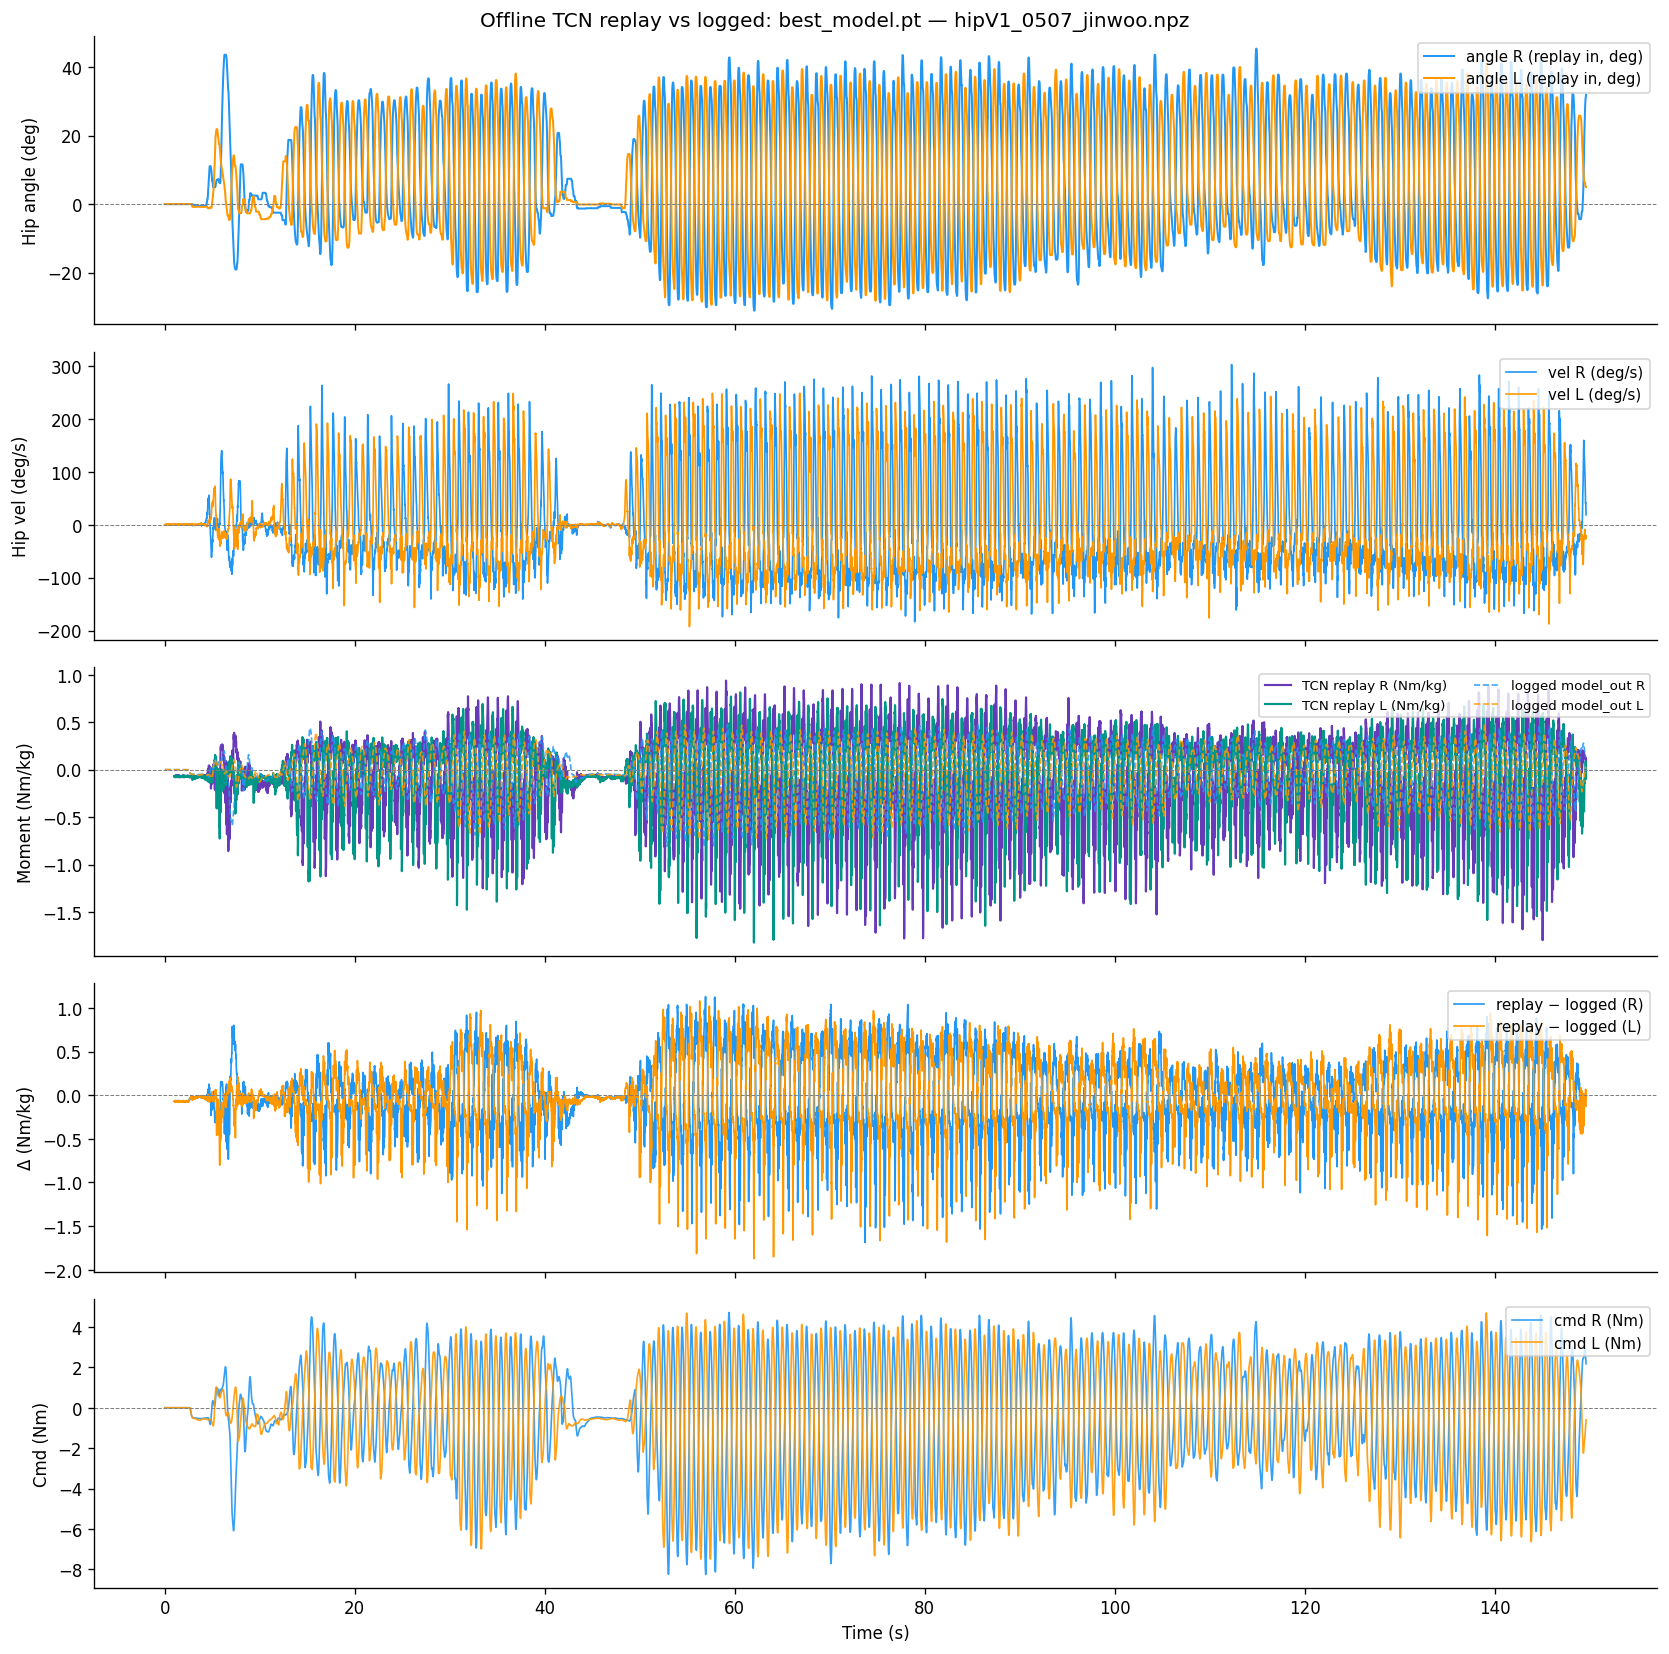

In [6]:
import sys
import io
from pathlib import Path

import torch
from IPython.display import Image, display

# Repo root: os_kinetics/ (contains model.py and runs/)
_cwd = Path.cwd().resolve()
_repo_candidates = [_cwd.parent.parent, _cwd.parent, _cwd]
_REPO = next((p for p in _repo_candidates if (p / "model.py").is_file()), None)
if _REPO is None:
    raise FileNotFoundError(
        "Could not find os_kinetics/model.py — cd to os_kinetics, hip-exo-ctrl, or hip-exo-ctrl/data_analysis."
    )
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from model import TCN

# Checkpoint used for on-device TRT (same training run as cascade engine when built from this .pt)
PT_PATH = _REPO / "runs" / "0421_ik_id_hip" / "best_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_off = torch.load(PT_PATH, map_location=device, weights_only=False)
cfg_m = ckpt_off["model_config"]
W = int(ckpt_off["window_size"])
norm = ckpt_off["normalization"]
pos_mean = np.asarray(norm["pos_mean"], dtype=np.float64)
pos_std = np.asarray(norm["pos_std"], dtype=np.float64)
vel_mean = np.asarray(norm["vel_mean"], dtype=np.float64)
vel_std = np.asarray(norm["vel_std"], dtype=np.float64)

in_idx = ckpt_off["input_indices"]  # [6, 13] hip_flexion_r, hip_flexion_l
idx_r, idx_l = int(in_idx[0]), int(in_idx[1])

# ── Build angle / velocity time series from .npz (same kinematics as CascadeHip) ──
ang_r = hip_pos_R.astype(np.float64)
ang_l = hip_pos_L.astype(np.float64)

gyro_p = np.deg2rad(d["imu_P"][:, 4].astype(np.float64))
vel_r = -np.deg2rad(d["imu_R"][:, 4].astype(np.float64)) - gyro_p
vel_l = -np.deg2rad(d["imu_L"][:, 4].astype(np.float64)) - gyro_p

# Normalize per training (single-DOF slice indices into full IK stats vectors)
pos_n_r = ang_r
vel_n_r = vel_r
pos_n_l = ang_l
vel_n_l = vel_l

model_replay = TCN(**cfg_m).eval().to(device)
model_replay.load_state_dict(ckpt_off["model_state_dict"])

n = len(time)
pred_r = np.full(n, np.nan, dtype=np.float64)
pred_l = np.full(n, np.nan, dtype=np.float64)

with torch.no_grad():
    for t_end in range(W - 1, n):
        i0 = t_end - W + 1
        x_r = np.stack([pos_n_r[i0 : t_end + 1], vel_n_r[i0 : t_end + 1]], axis=0)  # (2, W)
        x_l = np.stack([pos_n_l[i0 : t_end + 1], vel_n_l[i0 : t_end + 1]], axis=0)
        x_b = np.stack([x_r, x_l], axis=0)  # (2, 2, W)
        xt = torch.from_numpy(x_b.astype(np.float32)).to(device)
        y = model_replay(xt)[:, :, -1]  # (2, 1) last timestep, matches TRT export
        pred_r[t_end] = float(y[0, 0].cpu())
        pred_l[t_end] = float(y[1, 0].cpu())

valid = np.isfinite(pred_r)
print(f"Replay model: {PT_PATH.name}  |  window={W}  |  device={device}")
print(f"Valid replay samples: {valid.sum()} / {n}")

# ── Plot (static full-trial figure, same palette style as above) ──
fig2, axs2 = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
tplot = time

axs2[0].plot(tplot, np.rad2deg(ang_r), color=PALETTE["R"], lw=1.2, label="angle R (replay in, deg)")
axs2[0].plot(tplot, np.rad2deg(ang_l), color=PALETTE["L"], lw=1.2, label="angle L (replay in, deg)")
axs2[0].axhline(0, color="gray", lw=0.6, ls="--")
axs2[0].set_ylabel("Hip angle (deg)")
axs2[0].legend(fontsize=9, loc="upper right")

axs2[1].plot(tplot, np.rad2deg(vel_r), color=PALETTE["R"], lw=1.0, label="vel R (deg/s)")
axs2[1].plot(tplot, np.rad2deg(vel_l), color=PALETTE["L"], lw=1.0, label="vel L (deg/s)")
axs2[1].axhline(0, color="gray", lw=0.6, ls="--")
axs2[1].set_ylabel("Hip vel (deg/s)")
axs2[1].legend(fontsize=9, loc="upper right")

axs2[2].plot(tplot, pred_r, color="#673AB7", lw=1.3, label="TCN replay R (Nm/kg)")
axs2[2].plot(tplot, pred_l, color="#009688", lw=1.3, label="TCN replay L (Nm/kg)")
axs2[2].plot(tplot, model_out_R, color=PALETTE["R"], lw=1.0, ls="--", alpha=0.85, label="logged model_out R")
axs2[2].plot(tplot, model_out_L, color=PALETTE["L"], lw=1.0, ls="--", alpha=0.85, label="logged model_out L")
axs2[2].axhline(0, color="gray", lw=0.6, ls="--")
axs2[2].set_ylabel("Moment (Nm/kg)")
axs2[2].legend(fontsize=8, loc="upper right", ncol=2)

diff_r = pred_r - model_out_R
diff_l = pred_l - model_out_L
axs2[3].plot(tplot, diff_r, color=PALETTE["R"], lw=1.0, label="replay − logged (R)")
axs2[3].plot(tplot, diff_l, color=PALETTE["L"], lw=1.0, label="replay − logged (L)")
axs2[3].axhline(0, color="gray", lw=0.6, ls="--")
axs2[3].set_ylabel("Δ (Nm/kg)")
axs2[3].legend(fontsize=9, loc="upper right")

axs2[4].plot(tplot, cmd_R, color=PALETTE["R"], lw=1.0, alpha=0.9, label="cmd R (Nm)")
axs2[4].plot(tplot, cmd_L, color=PALETTE["L"], lw=1.0, alpha=0.9, label="cmd L (Nm)")
axs2[4].axhline(0, color="gray", lw=0.6, ls="--")
axs2[4].set_ylabel("Cmd (Nm)")
axs2[4].set_xlabel("Time (s)")
axs2[4].legend(fontsize=9, loc="upper right")

for ax in axs2:
    ax.spines[["top", "right"]].set_visible(False)

fig2.suptitle(f"Offline TCN replay vs logged: {PT_PATH.name} — {os.path.basename(FILE_PATH)}", fontsize=12)
plt.tight_layout()
_buf = io.BytesIO()
fig2.savefig(_buf, format="png", bbox_inches="tight", dpi=120)
plt.close(fig2)
_buf.seek(0)
display(Image(data=_buf.read()))
